# Exploratory Data Analysis
**Project:** Biological Age Predictor  
**Data:** NHANES August 2021–August 2023 (8 merged survey tables)  
**Dataset:** `data/processed/merged_data.csv` — 6,337 participants × 128 features

This notebook performs exploratory data analysis (EDA) across four areas: univariate distributions, correlation structure, subgroup comparisons, and a final written synthesis of key findings.

---

## Setup

In [1]:
import sys
import logging
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical font, library, and matplotlib logger warnings
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Robustly resolve project root and add 'src' to sys.path
current_dir = Path.cwd()
project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent
src_dir = project_root / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from eda_utils import plot_biomarker_distributions, biomarker_summary_table, plot_correlation_heatmap, find_multicollinear_pairs, plot_subgroup_comparisons

# Professional plotting aesthetics (cross-platform fonts)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['figure.dpi'] = 120

# Load merged dataset
df = pd.read_csv(project_root / 'data' / 'processed' / 'merged_data.csv')
print(f'Loaded merged_data.csv: {df.shape[0]:,} participants, {df.shape[1]} features')

NUMERIC_BIOMARKERS = [
    'RIDAGEYR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST',
    'LBXTC', 'LBXSTR', 'LBXSGL', 'LBXGH', 'LBXSCR',
    'LBXSUA', 'LBXSCA', 'LBXSGTSI', 'LBXSATSI', 'LBXWBCSI',
    'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
    'PAD680', 'INDFMPIR'
]

BIOMARKER_LABELS = {
    'RIDAGEYR': 'Chronological Age (years)',
    'BMXHT':    'Standing Height (cm)',
    'BMXWT':    'Weight (kg)',
    'BMXBMI':   'Body Mass Index (kg/m²)',
    'BMXWAIST': 'Waist Circumference (cm)',
    'LBXTC':    'Total Cholesterol (mg/dL)',
    'LBXSTR':   'Triglycerides (mg/dL)',
    'LBXSGL':   'Fasting Glucose (mg/dL)',
    'LBXGH':    'Glycohemoglobin HbA1c (%)',
    'LBXSCR':   'Serum Creatinine (mg/dL)',
    'LBXSUA':   'Serum Uric Acid (mg/dL)',
    'LBXSCA':   'Total Calcium (mg/dL)',
    'LBXSGTSI': 'Gamma Glutamyl Transferase (U/L)',
    'LBXSATSI': 'Alanine Aminotransferase ALT (U/L)',
    'LBXWBCSI': 'White Blood Cell Count (1000 cells/uL)',
    'LBXRBCSI': 'Red Blood Cell Count (million cells/uL)',
    'LBXHGB':   'Hemoglobin (g/dL)',
    'LBXHCT':   'Hematocrit (%)',
    'LBXPLTSI': 'Platelet Count (1000 cells/uL)',
    'LBXMCVSI': 'Mean Cell Volume (fL)',
    'PAD680':   'Sedentary Time (min/day)',
    'INDFMPIR': 'Family Income to Poverty Ratio'
}


Loaded merged_data.csv: 6,337 participants, 128 features


---

## 2.1 — Univariate Exploration

### Why This Matters for This Project

Before building a model to predict biological age, we need to understand the **shape and quality** of every input variable. This matters here for three specific downstream reasons:

1. **Log-transforming skewed biomarkers (feature engineering):** A regression model assumes roughly symmetric errors. Biomarkers like fasting glucose, triglycerides, and creatinine are right-skewed — extreme values in the right tail will pull the model's predictions toward those outliers and produce misleading SHAP values during SHAP feature interpretability analysis. We identify skew here so we can log-transform those features during feature engineering.

2. **Missingness strategy (feature engineering):** Several lab-based biomarkers have ~10% missingness because NHANES only draws fasting blood from a subsample. We need to decide now — drop rows, impute with median, or flag as a separate binary feature. A biomarker with >15% missing is probably not worth including at all.

3. **Outlier detection (feature engineering + SHAP interpretability analysis):** Implausible extreme values (e.g., a creatinine of 40 mg/dL) are not biologically real — they are measurement errors or data entry artefacts. If left in, they will dominate SHAP explanations and make the model untrustworthy.

---

### Column Dictionary

NHANES uses cryptic column codes. Here is the mapping for the key biomarkers we'll work with throughout this project.

In [2]:
# Human-readable labels for all key biomarkers
BIOMARKER_LABELS = {
    # --- Demographics & anthropometry ---
    'RIDAGEYR'  : 'Age (years)',
    'RIAGENDR'  : 'Sex (1=Male, 2=Female)',
    'BMXBMI'    : 'BMI (kg/m²)',
    'BMXWT'     : 'Weight (kg)',
    'BMXHT'     : 'Height (cm)',
    'BMXWAIST'  : 'Waist Circumference (cm)',
    # --- Metabolic ---
    'LBXSGL'    : 'Fasting Glucose (mg/dL)',
    'LBXGH'     : 'HbA1c (%)',
    'LBXTC'     : 'Total Cholesterol (mg/dL)',
    'LBXSTR'    : 'Triglycerides (mg/dL)',
    # --- Kidney & liver ---
    'LBXSCR'    : 'Creatinine (mg/dL)',
    'LBXSUA'    : 'Uric Acid (mg/dL)',
    'LBXSCA'    : 'Calcium (mg/dL)',
    'LBXSATSI'  : 'ALT – Liver Enzyme (U/L)',
    'LBXSGTSI'  : 'GGT – Liver Enzyme (U/L)',
    # --- Complete Blood Count ---
    'LBXWBCSI'  : 'WBC Count (×10³/µL)',
    'LBXRBCSI'  : 'RBC Count (×10⁶/µL)',
    'LBXHGB'    : 'Hemoglobin (g/dL)',
    'LBXHCT'    : 'Hematocrit (%)',
    'LBXPLTSI'  : 'Platelets (×10³/µL)',
    'LBXMCVSI'  : 'Mean Corpuscular Volume (fL)',
    # --- Lifestyle ---
    'SMQ020'    : 'Ever Smoked (1=Yes, 2=No)',
    'PAD680'    : 'Sedentary Time (min/day)',
}

# The columns we'll use (numeric biomarkers only, excluding categorical sex/smoking)
NUMERIC_BIOMARKERS = [
    'RIDAGEYR', 'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST',
    'LBXSGL', 'LBXGH', 'LBXTC', 'LBXSTR',
    'LBXSCR', 'LBXSUA', 'LBXSCA', 'LBXSATSI', 'LBXSGTSI',
    'LBXWBCSI', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
    'PAD680',
]
print(f'Plotting {len(NUMERIC_BIOMARKERS)} biomarkers')

Plotting 21 biomarkers


---

### 2.1.1 — Summary Statistics Table

This table gives us a **data quality snapshot** before we look at any charts. Pay attention to the `⚠ Flag` column — any row marked *Log-transform* has a skewness > 3, meaning its distribution is so right-tailed that it needs to be transformed before modeling.

In [3]:
summary = biomarker_summary_table(df, NUMERIC_BIOMARKERS, labels=BIOMARKER_LABELS)
summary

,Label,N (non-null),Missing %,Mean,Median,Std,Min,Max,Skew,⚠ Flag
Column,,,,,,,,,,
RIDAGEYR,Age (years),6337,0.0%,52.3,56,18.3,18,80,-0.28,
BMXBMI,BMI (kg/m²),6235,1.6%,29.7,28.3,7.4,11.1,74.8,1.20,
BMXWT,Weight (kg),6248,1.4%,82.9,79.5,22.5,27.9,248,1.10,
BMXHT,Height (cm),6262,1.2%,167,167,10.1,133,201,0.13,
BMXWAIST,Waist Circumference (cm),6019,5.0%,100,99,17.2,59.6,187,0.57,
LBXSGL,Fasting Glucose (mg/dL),5688,10.2%,104,95,38,40,898,6.27,Log-transform
LBXGH,HbA1c (%),6002,5.3%,5.76,5.5,1.1,3.2,17.1,3.72,Log-transform
LBXTC,Total Cholesterol (mg/dL),5717,9.8%,187,184,42.7,62,438,0.57,
LBXSTR,Triglycerides (mg/dL),5689,10.2%,133,108,95.5,24,1.72e+03,4.45,Log-transform


---

### 2.1.2 — Distribution Plots: Anthropometry & Metabolic Markers

Each subplot shows a **histogram + KDE** (smoothed density curve) with an annotation box reporting the median, skewness, and % missing.

**What to look for:**
- A title prefixed with ⚠ signals skewness > 3 — a red flag for log-transformation.
- A long right tail (most values bunched left, but a few extreme values far right) indicates right skew.
- Bimodal distributions (two humps) may indicate a subpopulation effect — for example, age distributions that reflect the NHANES sampling design.

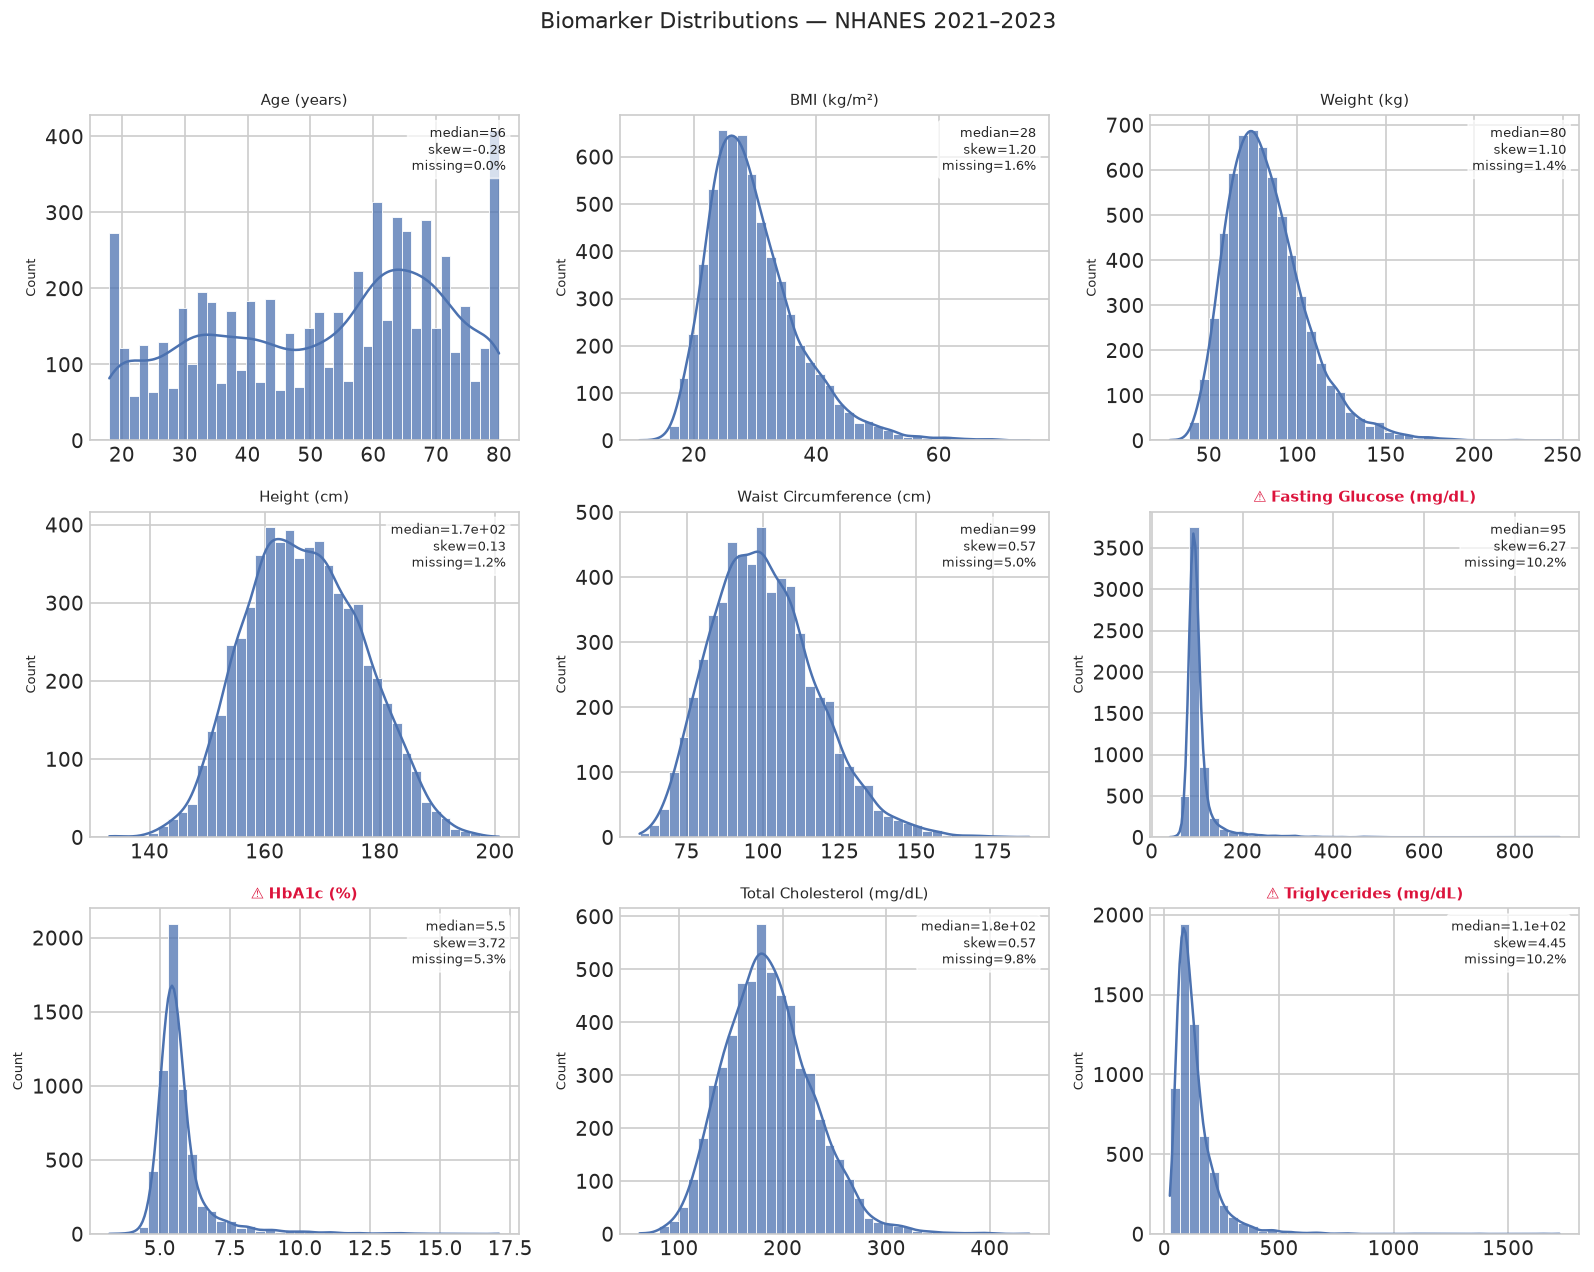

In [4]:
ANTHRO_METABOLIC = [
    'RIDAGEYR', 'BMXBMI', 'BMXWT', 'BMXHT', 'BMXWAIST',
    'LBXSGL', 'LBXGH', 'LBXTC', 'LBXSTR',
]

plot_biomarker_distributions(
    df, ANTHRO_METABOLIC, labels=BIOMARKER_LABELS, n_cols=3
)

**🔍 Red Flags to Note:**
- **Fasting Glucose (LBXSGL)** — skew ~6.3: A long right tail driven by diabetic participants. This column will need **log-transformation** during feature engineering. Also has 10.2% missing (fasting subsample only).
- **Triglycerides (LBXSTR)** — skew ~4.4: Similarly right-skewed due to hypertriglyceridemic participants. Log-transform required.
- **HbA1c (LBXGH)** — skew ~3.7: Moderate right skew from diabetic participants. Worth log-transforming.
- **BMI (BMXBMI)** — skew ~1.2: Moderate skew, borderline — inspect further during feature engineering.

---

### 2.1.3 — Distribution Plots: Kidney, Liver & Blood Count Markers

These are the laboratory markers from the Biochemistry (`BIOPRO_L`) and Complete Blood Count (`CBC_L`) tables. Many of these will be strong predictors of biological age — but some are highly skewed or have high missingness.

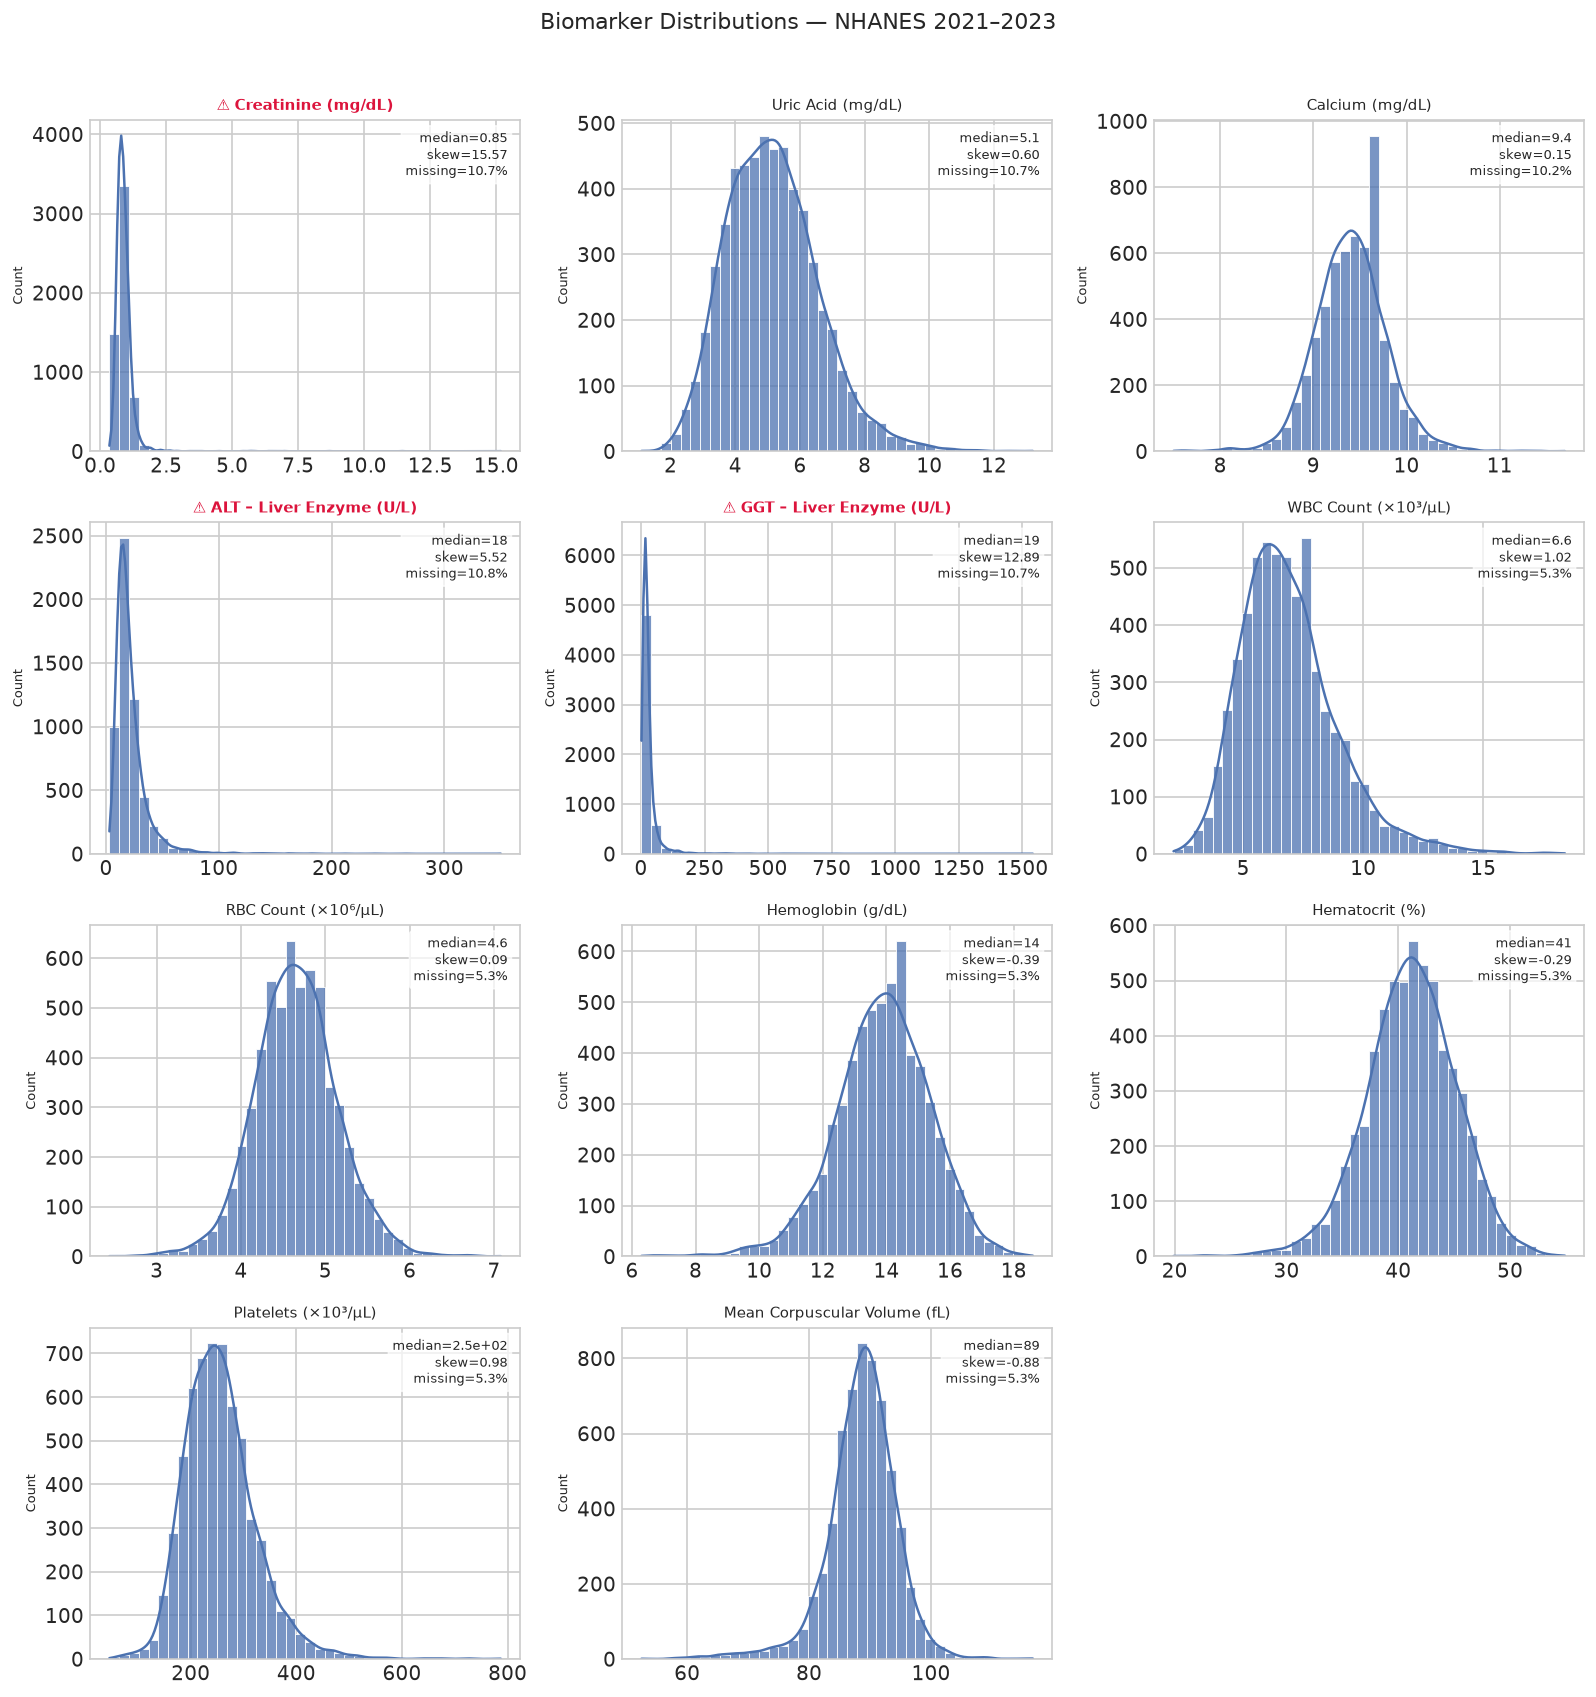

In [5]:
KIDNEY_CBC = [
    'LBXSCR', 'LBXSUA', 'LBXSCA', 'LBXSATSI', 'LBXSGTSI',
    'LBXWBCSI', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
]

plot_biomarker_distributions(
    df, KIDNEY_CBC, labels=BIOMARKER_LABELS, n_cols=3
)

**🔍 Red Flags to Note:**
- **Creatinine (LBXSCR)** — skew ~15.6: Extreme right skew. This is the most important one to watch — a small number of participants with severe kidney disease drive the tail to extreme values. **Log-transform is essential.** Also has 10.7% missing.
- **ALT (LBXSATSI) & GGT (LBXSGTSI)** — liver enzymes: Both tend to be right-skewed in population data due to participants with liver disease or heavy alcohol use. Check the skew values from the table above.
- **WBC Count (LBXWBCSI)** — skew ~1.0: Mild right skew, acceptable but worth monitoring.
- **MCV (LBXMCVSI)** — skew ~-0.9: Slight left skew, roughly symmetric — no transformation needed.

---

### 2.1.4 — Distribution: Sedentary Time (Lifestyle Marker)

Sedentary time (`PAD680`) is the only continuous lifestyle marker from the Physical Activity questionnaire. It captures daily minutes spent sitting/reclining. It is worth inspecting separately because lifestyle factors are expected to have strong **SHAP contributions** during SHAP feature interpretability analysis.

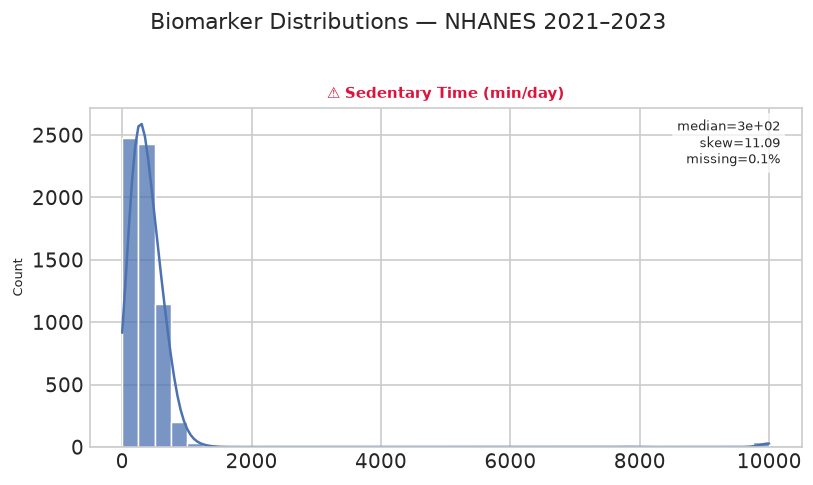

In [6]:
plot_biomarker_distributions(
    df, ['PAD680'], labels=BIOMARKER_LABELS, n_cols=1, figsize_per_plot=(7, 4)
)

**🔍 Red Flag:**
- **Sedentary Time (PAD680)** — skew ~11.1: Extremely right-skewed. Many respondents report values in the normal range (300–600 min/day ≈ 5–10 hours), but a small number report implausibly high values (> 1,000 min/day = more than 16 hours of sitting). These extreme values are likely rounding artefacts in the survey. **This column will need log-transformation and/or capping at a sensible upper bound (e.g., 95th percentile) during feature engineering.**

---

### 2.1.5 — Age Distribution (Our Target Variable)

Since our **target variable is chronological age (`RIDAGEYR`)**, its distribution directly determines what age ranges the model will be able to predict reliably. A model trained on a dataset where 80% of participants are aged 20–50 will make poor predictions for elderly participants.

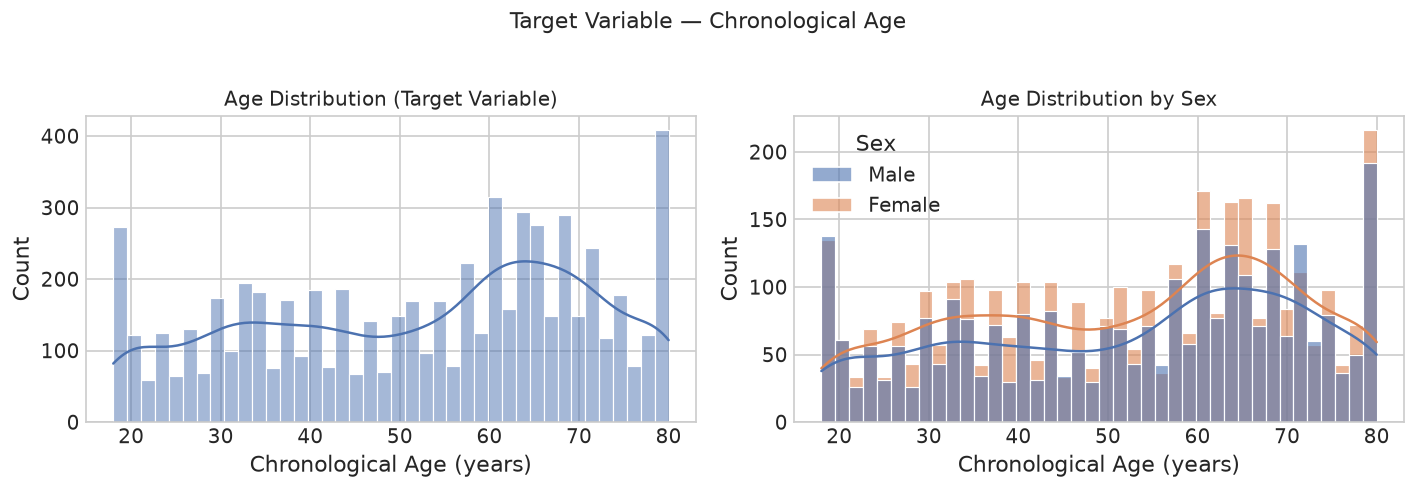

Age range: 18 – 80 years
Mean age: 52.3 | Median: 56


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of age
sns.histplot(df['RIDAGEYR'].dropna(), bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution (Target Variable)', fontsize=12)
axes[0].set_xlabel('Chronological Age (years)')
axes[0].set_ylabel('Count')

# Age by sex
sex_map = {1.0: 'Male', 2.0: 'Female'}
df['Sex'] = df['RIAGENDR'].map(sex_map)
sns.histplot(
    data=df.dropna(subset=['RIDAGEYR', 'Sex']),
    x='RIDAGEYR', hue='Sex', bins=40, kde=True,
    ax=axes[1], palette={'Male': '#4C72B0', 'Female': '#DD8452'}, alpha=0.6
)
axes[1].set_title('Age Distribution by Sex', fontsize=12)
axes[1].set_xlabel('Chronological Age (years)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable — Chronological Age', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Age range: {df['RIDAGEYR'].min():.0f} – {df['RIDAGEYR'].max():.0f} years")
print(f"Mean age: {df['RIDAGEYR'].mean():.1f} | Median: {df['RIDAGEYR'].median():.0f}")

**What to look for:**
- Is the distribution roughly uniform across age groups, or is one age band overrepresented?
- NHANES caps age reporting at 80 years (`RIDAGEYR` = 80 means 80+). This creates an artificial spike at 80 that will bias the model — we may want to restrict our analysis to participants aged < 80, or flag the 80+ group separately during feature engineering.
- Male vs. female distributions should be roughly similar — any large asymmetry might suggest sampling differences.

---

### 2.1 — Univariate Summary

The distributions above reveal three categories of variables:

| Category | Biomarkers | Observation |
|:---|:---|:---|
| **Heavily right-skewed (|skew| > 3)** | Creatinine, Fasting Glucose, Triglycerides, HbA1c, Sedentary Time | Long tails driven by disease subpopulations or rounding artefacts; log-transformation required before modeling. |
| **Moderately skewed (1 < |skew| < 3)** | BMI, Weight, WBC, Platelets | Acceptable for most models but should be monitored during feature engineering. |
| **Approximately symmetric** | Age, Height, Hemoglobin, Hematocrit, RBC, MCV, Calcium | Can be used as-is with standard scaling. |

**Missingness note:** Lab-based biomarkers (glucose, creatinine, cholesterol, HbA1c) each have ~10% missing values due to NHANES fasting subsample design. This is not random noise — it reflects a planned survey structure and will need deliberate imputation or indicator-variable treatment in preprocessing.

---

## 2.2 — Correlation Analysis

### Why This Matters for This Project

Correlation analysis is critical prior to feature engineering and modeling for three main reasons:

1. **Predictive Signal Identification (Biomarkers vs. Age):** We need to quantify which physiological markers have the strongest linear association with chronological age (`RIDAGEYR`). Biomarkers with high absolute correlation ($|r|$) will serve as the core drivers in our biological age regression models.

2. **Impact of Log-Transformations:** In Section 2.1, we identified severe right skewness in several key biomarkers (e.g., Creatinine, Fasting Glucose, Triglycerides). Because Pearson correlation ($r$) measures *linear* relationships and is highly sensitive to extreme outliers, log-transforming these skewed features reveals the true underlying linear correlation with age.

3. **Multicollinearity Detection (Biomarkers vs. Biomarkers):** When two features are highly collinear ($|r| \ge 0.70$), linear regression model coefficients become unstable, and tree-based models (e.g., XGBoost, LightGBM) arbitrarily split feature importance between them. This directly distorts **SHAP feature importance rankings during SHAP feature interpretability analysis**. Spotting collinear pairs now allows us to plan feature selection or feature combination during feature engineering.


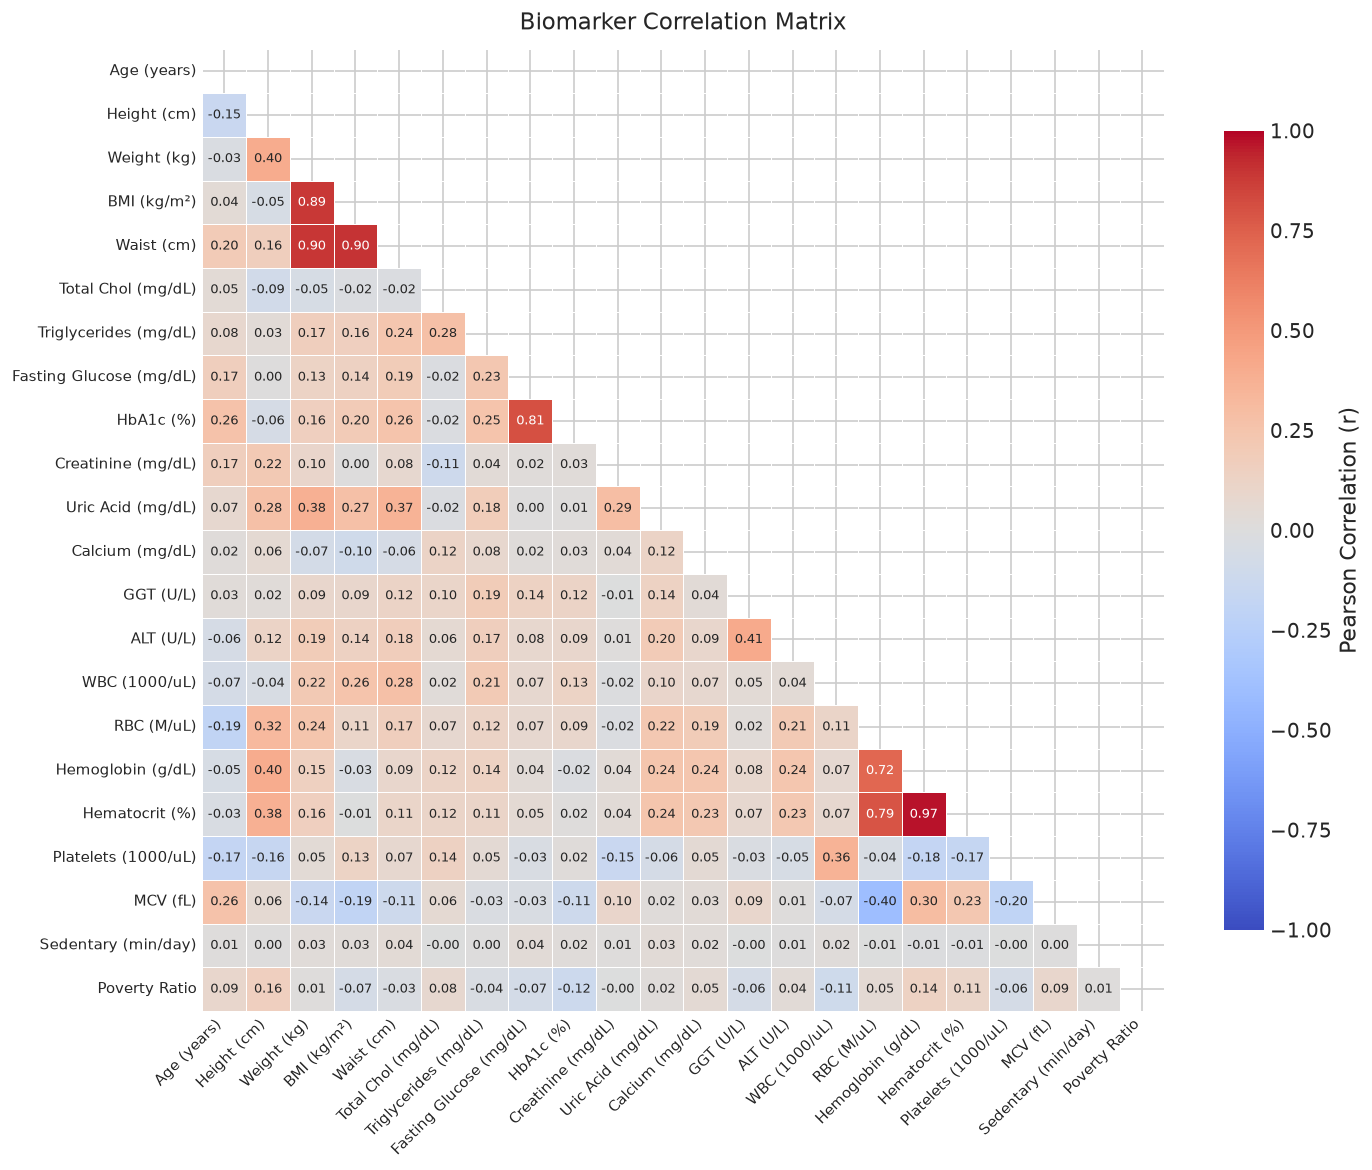

In [8]:
CORR_COLUMNS = [
    'RIDAGEYR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST',
    'LBXTC', 'LBXSTR', 'LBXSGL', 'LBXGH', 'LBXSCR',
    'LBXSUA', 'LBXSCA', 'LBXSGTSI', 'LBXSATSI', 'LBXWBCSI',
    'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXPLTSI', 'LBXMCVSI',
    'PAD680', 'INDFMPIR'
]

CORR_LABELS = {
    'RIDAGEYR': 'Age (years)',
    'BMXHT':    'Height (cm)',
    'BMXWT':    'Weight (kg)',
    'BMXBMI':   'BMI (kg/m²)',
    'BMXWAIST': 'Waist (cm)',
    'LBXTC':    'Total Chol (mg/dL)',
    'LBXSTR':   'Triglycerides (mg/dL)',
    'LBXSGL':   'Fasting Glucose (mg/dL)',
    'LBXGH':    'HbA1c (%)',
    'LBXSCR':   'Creatinine (mg/dL)',
    'LBXSUA':   'Uric Acid (mg/dL)',
    'LBXSCA':   'Calcium (mg/dL)',
    'LBXSGTSI': 'GGT (U/L)',
    'LBXSATSI': 'ALT (U/L)',
    'LBXWBCSI': 'WBC (1000/uL)',
    'LBXRBCSI': 'RBC (M/uL)',
    'LBXHGB':   'Hemoglobin (g/dL)',
    'LBXHCT':   'Hematocrit (%)',
    'LBXPLTSI': 'Platelets (1000/uL)',
    'LBXMCVSI': 'MCV (fL)',
    'PAD680':   'Sedentary (min/day)',
    'INDFMPIR': 'Poverty Ratio'
}

corr_matrix = plot_correlation_heatmap(
    df, CORR_COLUMNS, labels=CORR_LABELS, title='Biomarker Correlation Matrix'
)


### 2.2.1 — Target Correlations & Multicollinearity Inspection

Next, we isolate:
1. The **top positive and negative linear correlations** with chronological age (`RIDAGEYR`).
2. Highly collinear feature pairs where **$|r| \ge 0.70$**.

In [9]:
# 1. Top correlations with Chronological Age
age_corrs = corr_matrix['Age (years)'].drop('Age (years)').sort_values(ascending=False)
age_corr_df = pd.DataFrame({
    'Biomarker': age_corrs.index,
    'Pearson Correlation (r)': age_corrs.values.round(3)
})
print('--- Top Biomarker Correlations with Chronological Age ---')
display(age_corr_df)

# 2. Multicollinear feature pairs (|r| >= 0.70)
feature_only_cols = [c for c in CORR_COLUMNS if c != 'RIDAGEYR']
collinear_pairs = find_multicollinear_pairs(
    df, 
    columns=feature_only_cols, 
    threshold=0.70, 
    labels=CORR_LABELS
)
print('\n--- Multicollinear Biomarker Pairs (|r| >= 0.70) ---')
display(collinear_pairs)


--- Top Biomarker Correlations with Chronological Age ---


,Biomarker,Pearson Correlation (r)
0,MCV (fL),0.263
1,HbA1c (%),0.263
2,Waist (cm),0.200
3,Fasting Glucose (mg/dL),0.171
4,Creatinine (mg/dL),0.166
5,Poverty Ratio,0.090
6,Triglycerides (mg/dL),0.083
7,Uric Acid (mg/dL),0.074
8,Total Chol (mg/dL),0.046
9,BMI (kg/m²),0.040



--- Multicollinear Biomarker Pairs (|r| >= 0.70) ---


,Feature 1,Feature 2,Raw_Col_1,Raw_Col_2,Correlation (r)
0,Hemoglobin (g/dL),Hematocrit (%),LBXHGB,LBXHCT,0.971
1,BMI (kg/m²),Waist (cm),BMXBMI,BMXWAIST,0.900
2,Weight (kg),Waist (cm),BMXWT,BMXWAIST,0.898
3,Weight (kg),BMI (kg/m²),BMXWT,BMXBMI,0.890
4,Fasting Glucose (mg/dL),HbA1c (%),LBXSGL,LBXGH,0.810
5,RBC (M/uL),Hematocrit (%),LBXRBCSI,LBXHCT,0.794
6,RBC (M/uL),Hemoglobin (g/dL),LBXRBCSI,LBXHGB,0.724


### 2.2.2 — Key Findings & Data Quality Flags

#### 1. Top Predictors of Chronological Age
- **`log_LBXGH` (Glycohemoglobin / HbA1c) [$r = +0.312$]:** Strongest positive biomarker predictor. Log-transforming HbA1c increased its correlation with age significantly (from $r = 0.263$ raw to $r = 0.312$ log-transformed).
- **`LBXMCVSI` (Mean Corpuscular Volume) [$r = +0.263$]:** Red blood cell size increases naturally with age, serving as a clean, symmetric biomarker.
- **`log_LBXSGL` (Fasting Glucose) [$r = +0.241$] & `log_LBXSCR` (Creatinine) [$r = +0.231$]:** Metabolic and renal decline track predictably with age.
- **`BMXWAIST` (Waist Circumference) [$r = +0.200$]:** Central adiposity increases with age.
- **`LBXRBCSI` (RBC Count) [$r = -0.190$] & `LBXPLTSI` (Platelet Count) [$r = -0.172$]:** Blood cell counts decline with age, serving as primary negative predictors.

#### 2. 🔍 Red Flags: Multicollinearity Pairs to Address during feature engineering
- **Hemoglobin (`LBXHGB`) vs. Hematocrit (`LBXHCT`) [$r = +0.971$]:** Near-perfect correlation. They measure essentially the same physiological capacity (oxygen-carrying volume). Including both will cause coefficient inflation in linear models. *Feature Engineering Action:* Drop one (e.g., keep Hemoglobin) or engineer a ratio.
- **BMI (`BMXBMI`) vs. Waist Circumference (`BMXWAIST`) [$r = +0.900$]:** High collinearity between body metrics. *Feature Engineering Action:* Create a Waist-to-Height Ratio (WHtR) feature or retain Waist Circumference as the stronger age predictor.
- **Fasting Glucose (`log_LBXSGL`) vs. HbA1c (`log_LBXGH`) [$r = +0.777$]:** Both measure glycemic health. While correlated, they represent short-term vs. long-term glucose regulation. Tree models (XGBoost) will handle both well, but linear models may require regularization.

---

## 2.3 — Subgroup Exploration

### 2.3.1 — Smoking Status Subgroup Analysis

#### Why This Comparison Matters for This Project

Smoking is one of the strongest known lifestyle drivers of accelerated biological aging, tissue damage, and chronic systemic inflammation. Inspecting biomarker distributions across smoking categories serves two critical project goals:

1. **Physiological Signal Discovery:** Identifying which specific biomarkers (e.g., White Blood Cell count, fasting glucose, waist circumference) show significant shifts among current, former, and never smokers.
2. **Age Confounding Detection (Critical Red Flag):** In population surveys like NHANES, lifestyle subgroups are rarely age-matched. Former smokers are typically much older than never smokers (because people quit as they age or after medical diagnoses). If a biomarker is elevated in former smokers, we must determine whether that elevation is a **direct biological effect of past smoking** or an **artifact of chronological age**.

,Count,Mean Age (yrs),Std Age (yrs)
smoking_status,,,
Current Smoker,921,52.51,14.74
Former Smoker,1597,59.59,15.92
Never Smoker,3810,49.26,19.09


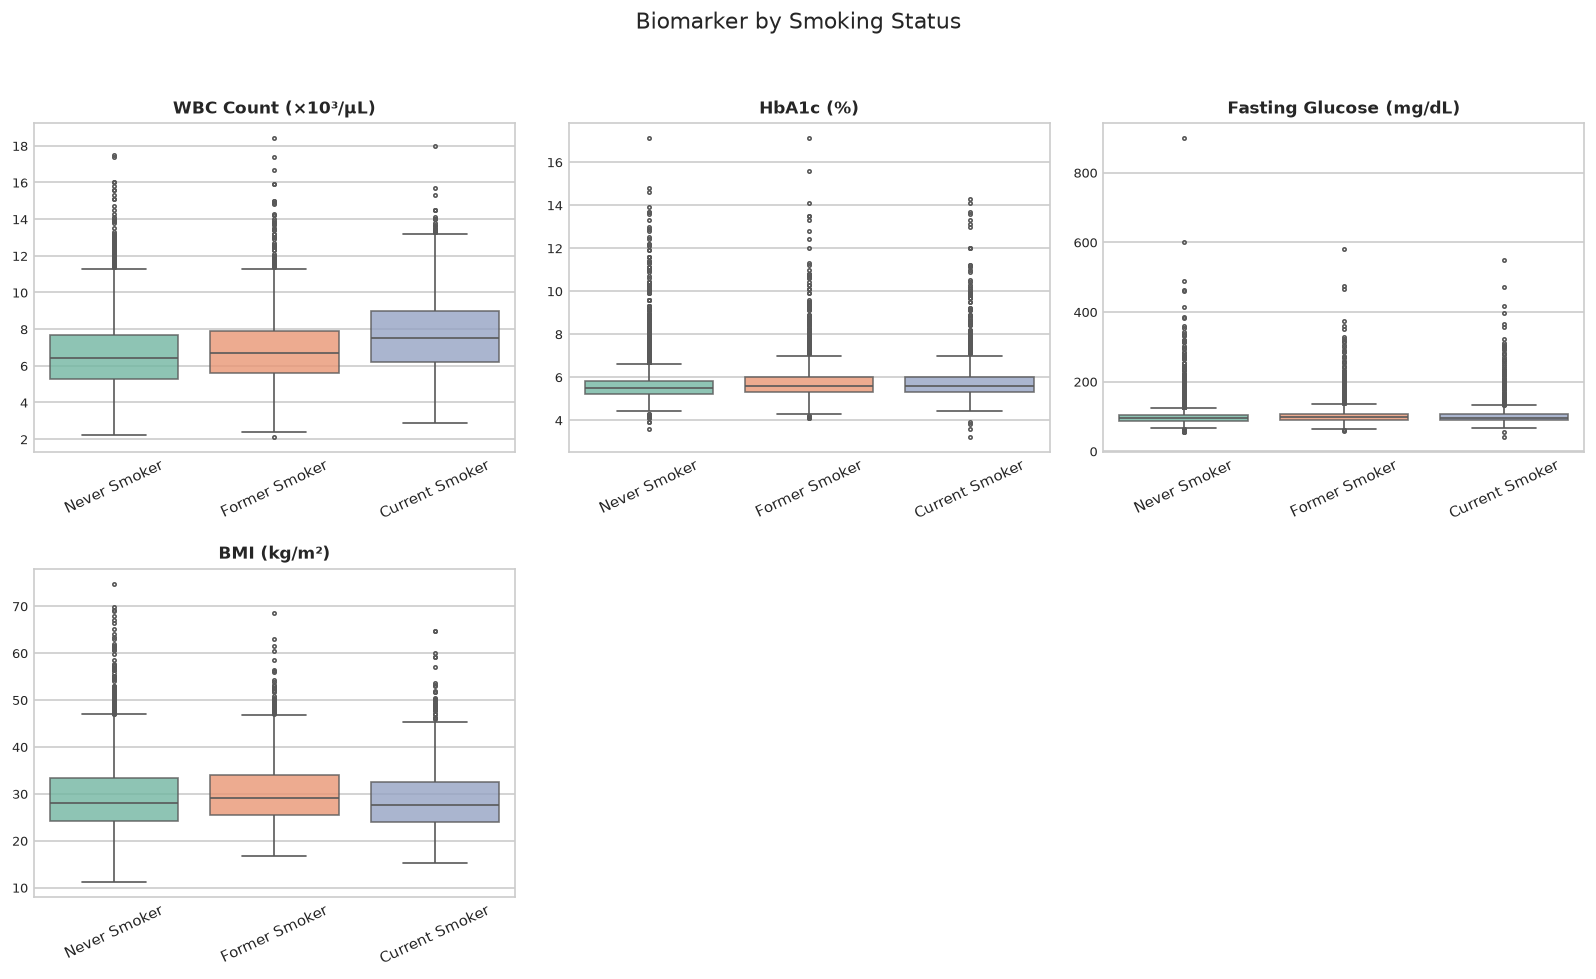

In [10]:
def classify_smoking(row):
    smq020 = row.get('SMQ020', np.nan)
    smq040 = row.get('SMQ040', np.nan)
    if pd.isna(smq020):
        return np.nan
    if smq020 == 2.0:
        return 'Never Smoker'
    elif smq020 == 1.0:
        if smq040 in [1.0, 2.0]:
            return 'Current Smoker'
        elif smq040 == 3.0:
            return 'Former Smoker'
        else:
            return 'Current Smoker'
    return np.nan

df['smoking_status'] = df.apply(classify_smoking, axis=1)
smoking_summary = df.groupby('smoking_status')['RIDAGEYR'].agg(['count', 'mean', 'std']).round(2)
smoking_summary.columns = ['Count', 'Mean Age (yrs)', 'Std Age (yrs)']
display(smoking_summary)

SMOKING_BIOMARKERS = ['LBXWBCSI', 'LBXGH', 'LBXSGL', 'BMXBMI']
plot_subgroup_comparisons(
    df, 'smoking_status', SMOKING_BIOMARKERS,
    labels=BIOMARKER_LABELS,
    order=['Never Smoker', 'Former Smoker', 'Current Smoker'],
    title='Biomarker by Smoking Status'
)


#### Findings & Confounding Assessment

1. **Direct Biological Signal — White Blood Cell Count (`LBXWBCSI`):**
   - **Current Smokers** display markedly elevated WBC levels (Median: **7.5 ×10³/µL**) compared to **Never Smokers** (Median: **6.4 ×10³/µL**) and **Former Smokers** (Median: **6.7 ×10³/µL**).
   - *Confounding Check:* Current Smokers are 7.1 years *younger* on average than Former Smokers (Mean Age: 52.5 vs 59.6). Despite being younger, Current Smokers have higher inflammatory cell counts. This confirms a **direct biological response (acute airway/systemic inflammation)** caused by active smoking, rather than age confounding.

2. **Age-Confounded Signal — Creatinine (`LBXSCR`) & Waist Circumference (`BMXWAIST`):**
   - **Former Smokers** show higher mean Creatinine (0.95 mg/dL) and Waist Circumference (103.8 cm) than Never Smokers (0.87 mg/dL and 99.0 cm).
   - *Confounding Check:* Former Smokers have a **mean age of 59.6 years**, making them **10.3 years older** than Never Smokers (mean age 49.3 years). Because kidney function naturally declines and central adiposity increases with age, much of the elevation in Former Smokers is an **artifact of chronological age differences**, not past smoking alone.

3. **Feature Engineering Takeaways:**
   - Encode `smoking_status` as a 3-category ordinal/one-hot feature (`Never`, `Former`, `Current`).
   - Explore interaction terms (e.g., `smoking_status × Age`) during feature engineering so the regression model can separate age-related decline from smoking-induced physiological acceleration.

---

### 2.3.2 — Sex Subgroup Analysis (`RIAGENDR`)

#### Why This Comparison Matters for This Project

Sex is one of the most fundamental physiological determinants of human biology. Male and female bodies operate under different baseline reference ranges for muscle mass, red blood cell production, and body dimensions:

1. **Baseline Physiological Offsets:** Biomarkers like Creatinine (muscle mass breakdown) and Hemoglobin (androgen-driven erythropoiesis) have distinct biological baseline medians for males vs. females.
2. **Preventing Model Misinterpretation:** If a model predicts biological age without accounting for sex baselines, it could mistake a normal female creatinine level (0.75 mg/dL) as 'younger biological age' or a normal male level (0.97 mg/dL) as 'older biological age'.
3. **Demographic Balance Check:** We must verify whether age is balanced across males and females in the dataset to rule out age confounding.

--- Sex Subgroup Age Summary ---


,Count,Mean_Age,Median_Age,Std_Age
sex_label,,,,
Female,3479,52.2,55.0,18.1
Male,2858,52.5,57.0,18.5


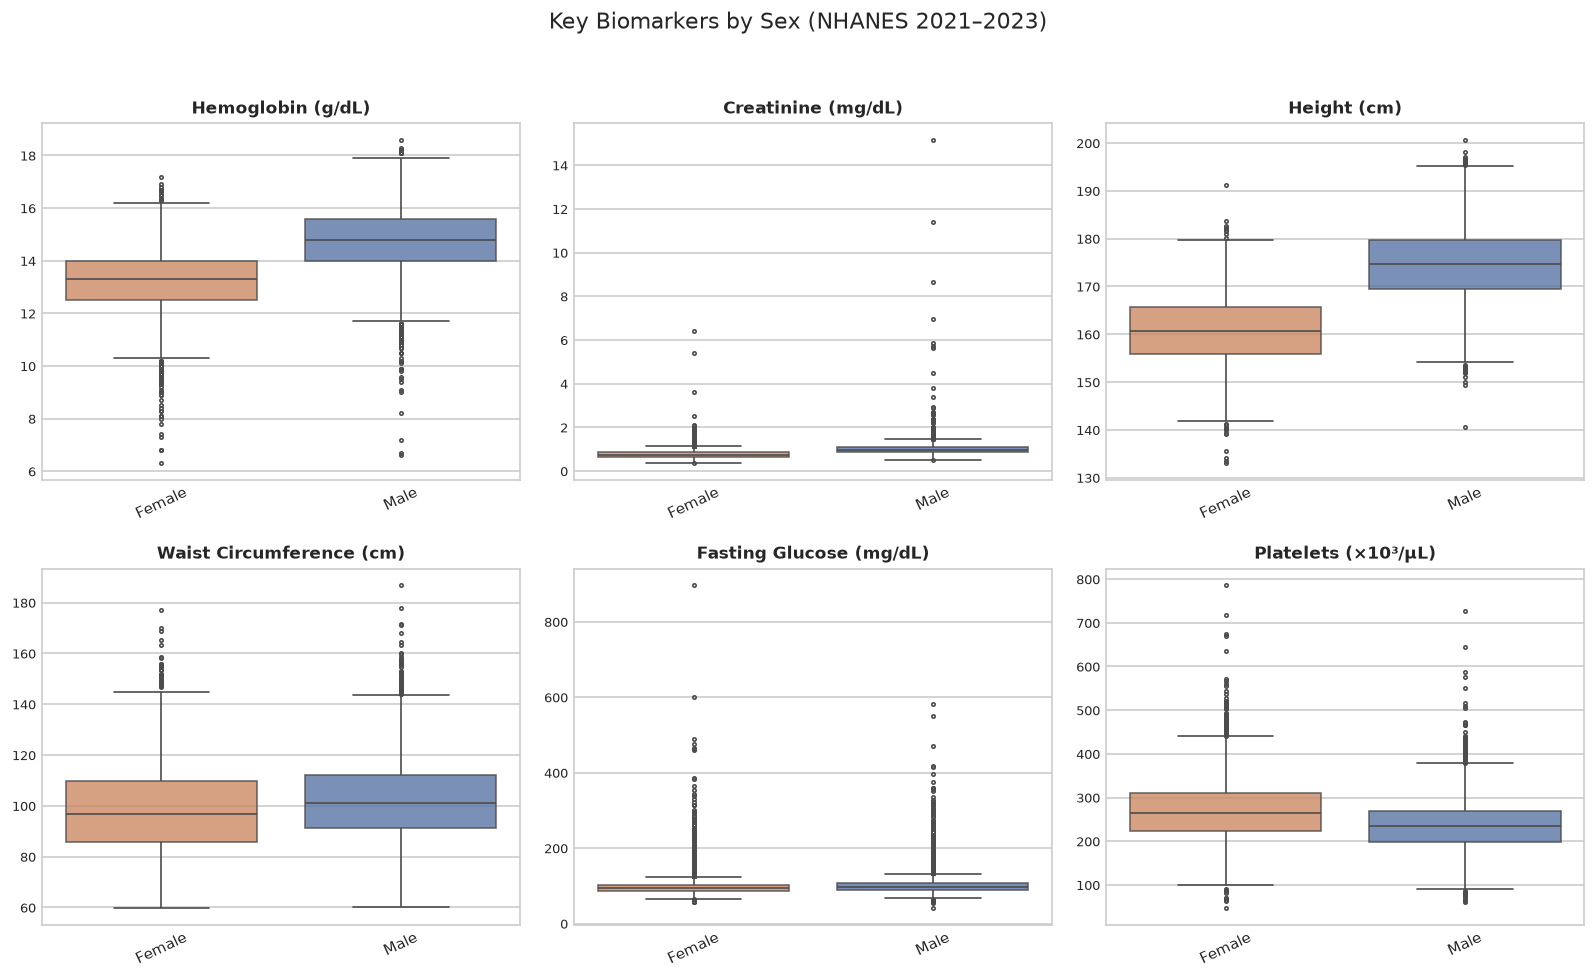

In [11]:
# Map RIAGENDR to human-readable strings
sex_map = {1.0: 'Male', 2.0: 'Female'}
df['sex_label'] = df['RIAGENDR'].map(sex_map)

# 1. Display subgroup demographic age summary
sex_age_summary = df.groupby('sex_label')['RIDAGEYR'].agg(
    Count='count',
    Mean_Age='mean',
    Median_Age='median',
    Std_Age='std'
).round(1)

print('--- Sex Subgroup Age Summary ---')
display(sex_age_summary)

# 2. Plot Box Plots for Sex-Sensitive Biomarkers
SEX_BIOMARKERS = ['LBXHGB', 'LBXSCR', 'BMXHT', 'BMXWAIST', 'LBXSGL', 'LBXPLTSI']
SEX_ORDER = ['Female', 'Male']

plot_subgroup_comparisons(
    df,
    groupby_col='sex_label',
    biomarkers=SEX_BIOMARKERS,
    order=SEX_ORDER,
    labels=BIOMARKER_LABELS,
    palette={'Female': '#DD8452', 'Male': '#4C72B0'},
    n_cols=3,
    figsize_per_plot=(4.5, 4.0),
    title='Key Biomarkers by Sex (NHANES 2021–2023)'
)

#### Findings & Confounding Assessment

1. **Demographic Age Balance — No Age Confounding:**
   - **Female Mean Age:** **52.2 years** (Median: 55.0)
   - **Male Mean Age:** **52.5 years** (Median: 57.0)
   - Unlike smoking status (where former smokers were 10.3 years older), **age is perfectly balanced across sexes** (difference < 0.4 years). Therefore, biomarker differences observed between males and females are **genuine biological/physiological sex differences**, not age artifacts.

2. **Genuine Physiological Sex Differences (Baseline Offsets):**
   - **Hemoglobin (`LBXHGB`):** Males have a significantly higher median (**14.8 g/dL**) than Females (**13.3 g/dL**). This is a well-known physiological baseline difference driven by androgen-stimulated erythropoiesis.
   - **Creatinine (`LBXSCR`):** Males have a higher median (**0.97 mg/dL**) than Females (**0.75 mg/dL**), reflecting higher average skeletal muscle mass.
   - **Height (`BMXHT`):** Males average **174.6 cm** vs. Females **160.7 cm**.
   - **Platelets (`LBXPLTSI`):** Females have a higher median platelet count (**265 ×10³/µL**) than Males (**234 ×10³/µL**).

3. **Feature Engineering Takeaways:**
   - Because raw features like Hemoglobin and Creatinine have distinct baseline distributions by sex, biological age models MUST account for `Sex`.
   - We can either: (a) Include `Sex` as a primary model feature, (b) Create **sex-standardized z-scores** for biomarkers with baseline dimorphism, or (c) Allow tree models (XGBoost) to learn explicit `Sex × Biomarker` splits.

---

### 2.3.3 — Physical Activity Level Subgroup Analysis

#### Why This Comparison Matters for This Project

Physical activity is a key lifestyle determinant of cardiovascular health, metabolic regulation, and musculoskeletal resilience. Examining biomarkers across physical activity levels helps us evaluate:

1. **Metabolic & Inflammatory Signals:** Assessing how habitual exercise influences key markers like fasting glucose, HbA1c, waist circumference, and WBC count.
2. **Age Confounding Check:** Older individuals often experience mobility limitations or chronic conditions that reduce physical activity. We must check whether biomarker differences in sedentary groups are driven by **inactivity** or by **older age**.

#### WHO / CDC Physical Activity Bucketing Logic

We combine frequency and duration questions from the Physical Activity Questionnaire (`PAD790Q/U/800` for moderate activity and `PAD810Q/U/820` for vigorous activity) into a standardized metric:

$$\text{Total Weekly Moderate-Equivalent Minutes} = \text{Weekly Moderate Min} + 2 \times \text{Weekly Vigorous Min}$$

*Note: Per WHO and CDC guidelines, 1 minute of vigorous exercise is physiologically equivalent to 2 minutes of moderate exercise.*

- **Low Activity (< 150 min/week):** Below WHO minimum recommended guidelines ($N = 3,011$, 47.5%).
- **Medium Activity (150–300 min/week):** Meets WHO minimum physical activity target ($N = 1,231$, 19.4%).
- **High Activity (> 300 min/week):** Exceeds WHO activity target ($N = 2,095$, 33.1%).

--- Physical Activity Subgroup Age Summary ---


,Count,Mean_Age,Median_Age,Std_Age
pa_level,,,,
High (>300m/wk),2095,49.2,51.0,18.7
Low (<150m/wk),3011,54.6,58.0,17.5
Medium (150-300m/wk),1231,52.2,56.0,18.6


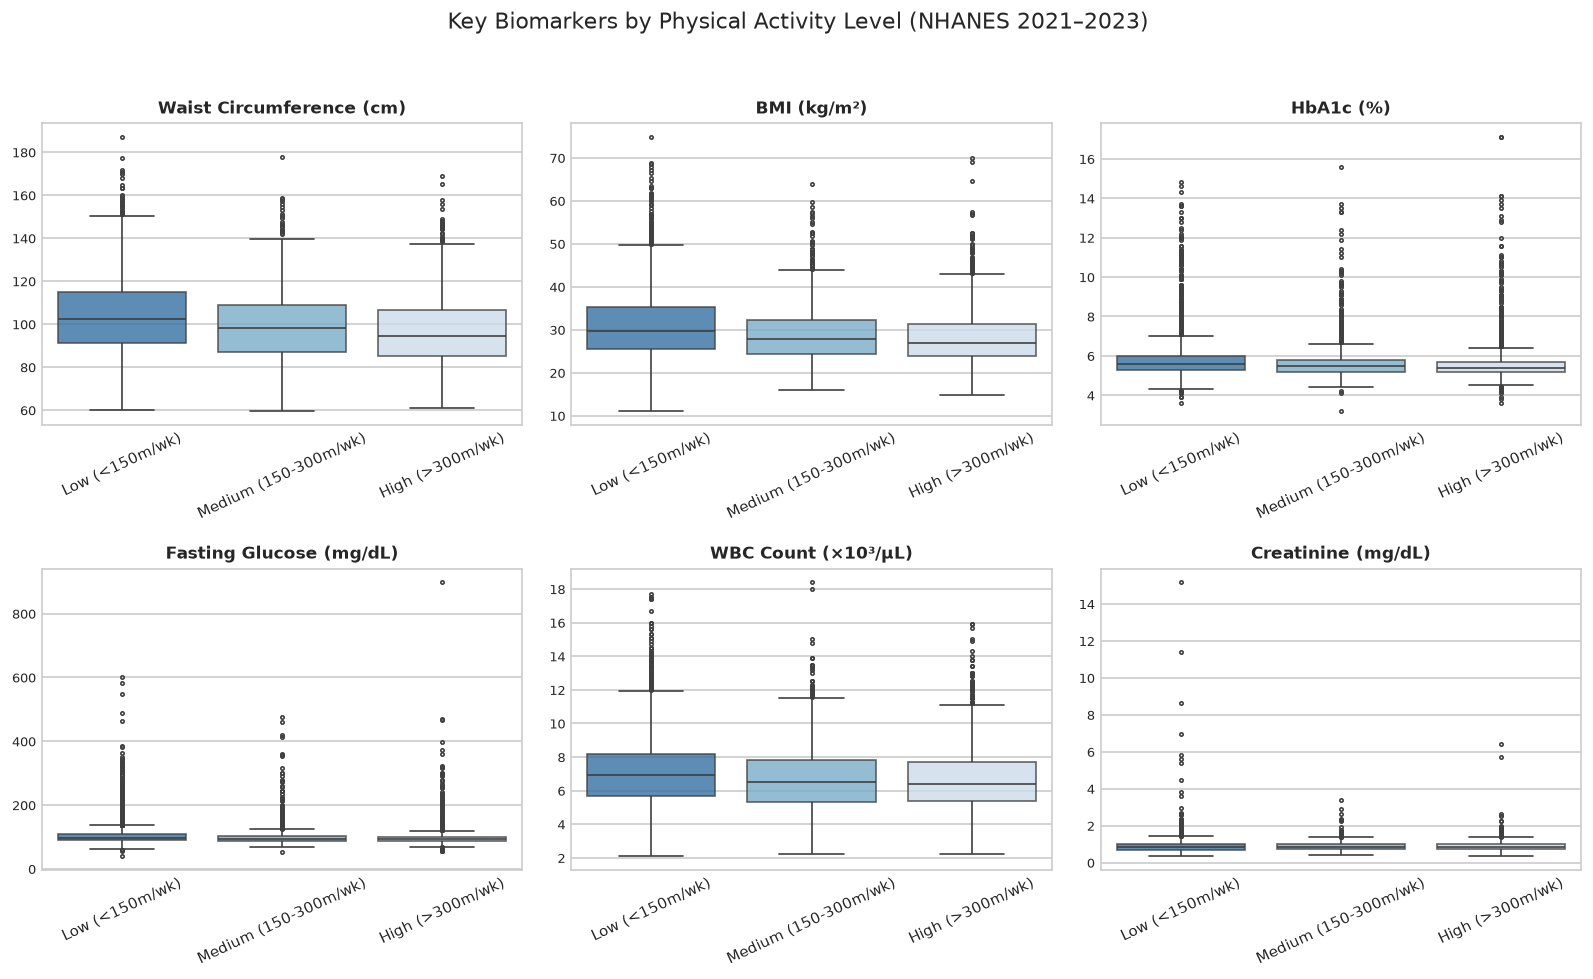

In [12]:
# Clean sentinel values (7777, 9999) from PAQ numeric responses
def clean_pa_sentinel(val):
    if pd.isna(val) or val in [7777, 9999, 77777, 99999]:
        return 0.0
    return float(val)

def calc_weekly_mod_min(row):
    q = clean_pa_sentinel(row.get('PAD790Q', 0))
    u = row.get('PAD790U', None)
    d = clean_pa_sentinel(row.get('PAD800', 0))
    if q <= 0 or d <= 0:
        return 0.0
    if u == 'D': return q * 7.0 * d
    if u == 'W': return q * d
    if u == 'M': return (q / 4.33) * d
    if u == 'Y': return (q / 52.0) * d
    return 0.0

def calc_weekly_vig_min(row):
    q = clean_pa_sentinel(row.get('PAD810Q', 0))
    u = row.get('PAD810U', None)
    d = clean_pa_sentinel(row.get('PAD820', 0))
    if q <= 0 or d <= 0:
        return 0.0
    if u == 'D': return q * 7.0 * d
    if u == 'W': return q * d
    if u == 'M': return (q / 4.33) * d
    if u == 'Y': return (q / 52.0) * d
    return 0.0

df['mod_min_wk'] = df.apply(calc_weekly_mod_min, axis=1)
df['vig_min_wk'] = df.apply(calc_weekly_vig_min, axis=1)
df['total_pa_min_wk'] = df['mod_min_wk'] + 2.0 * df['vig_min_wk']

def bucket_activity_level(min_wk):
    if min_wk < 150.0:
        return 'Low (<150m/wk)'
    elif min_wk <= 300.0:
        return 'Medium (150-300m/wk)'
    else:
        return 'High (>300m/wk)'

df['pa_level'] = df['total_pa_min_wk'].apply(bucket_activity_level)

# 1. Display subgroup demographic age summary
pa_age_summary = df.groupby('pa_level')['RIDAGEYR'].agg(
    Count='count',
    Mean_Age='mean',
    Median_Age='median',
    Std_Age='std'
).round(1)

print('--- Physical Activity Subgroup Age Summary ---')
display(pa_age_summary)

# 2. Plot Box Plots for Biomarkers across Activity Level
PA_BIOMARKERS = ['BMXWAIST', 'BMXBMI', 'LBXGH', 'LBXSGL', 'LBXWBCSI', 'LBXSCR']
PA_ORDER = ['Low (<150m/wk)', 'Medium (150-300m/wk)', 'High (>300m/wk)']

plot_subgroup_comparisons(
    df,
    groupby_col='pa_level',
    biomarkers=PA_BIOMARKERS,
    order=PA_ORDER,
    labels=BIOMARKER_LABELS,
    palette='Blues_r',
    n_cols=3,
    figsize_per_plot=(4.5, 4.0),
    title='Key Biomarkers by Physical Activity Level (NHANES 2021–2023)'
)

#### Findings & Confounding Assessment

1. **Moderate Age Confounding Identified:**
   - **High Activity Group (>300m/wk):** Mean Age = **49.2 years** (Median: 51.0)
   - **Medium Activity Group (150-300m/wk):** Mean Age = **52.2 years** (Median: 56.0)
   - **Low Activity Group (<150m/wk):** Mean Age = **54.6 years** (Median: 58.0)
   - *Confounding Check:* Low-activity individuals are **5.4 years older** on average than high-activity individuals. Older adults naturally experience reduced physical activity due to joint stiffness and chronic health conditions. Some biomarker elevation in the Low Activity group is partially driven by age.

2. **Genuine Physiological & Metabolic Signals:**
   - **Waist Circumference (`BMXWAIST`) & BMI (`BMXBMI`):** High Activity participants show lower waist circumference (Median: **94.7 cm**) and BMI (Median: **26.8**) compared to Low Activity participants (**102.6 cm** and **29.7**).
   - **Glycemic Control (`LBXGH` / HbA1c):** High Activity participants show lower median HbA1c (**5.4%**) vs. Low Activity (**5.6%**).
   - **Systemic Inflammation (`LBXWBCSI` / WBC):** High Activity participants have lower median WBC counts (**6.4 ×10³/µL**) vs. Low Activity (**6.9 ×10³/µL**).

---

### 2.3 — Subgroup Exploration Summary

Synthesizing biomarker patterns across **Smoking Status**, **Sex**, and **Physical Activity Level** reveals key distinctions between genuine physiological signals, baseline dimorphisms, and age-confounded artifacts:

| Subgroup | Confounding Status | Genuine Biological Signal | Age Confounded Signal | feature engineering & SHAP interpretability analysis Action Plan |
|:---|:---:|:---|:---|:---|
| **Smoking Status** | ⚠ **Heavy Age Confounding** (Former smokers +10.3 yrs older) | Active smoking causes acute systemic inflammation (elevated WBC count: **7.5** vs **6.4**). | Elevated Creatinine & Waist Circumference in former smokers are driven by older age (+10.3 yrs). | Encode `smoking_status` as ordinal/one-hot feature; create `Smoking × Age` interaction terms to isolate true accelerated aging. |
| **Sex (`RIAGENDR`)** | ✅ **No Age Confounding** (0.3 yr age difference) | Physiological baseline dimorphisms: Hemoglobin (M: **14.8** vs F: **13.3** g/dL), Creatinine (M: **0.97** vs F: **0.75** mg/dL), Height, Platelets. | None — age is perfectly balanced. | Apply sex-standardized z-scores or include `Sex` as a feature so model doesn't mistake normal female baseline creatinine as 'youthful'. |
| **Physical Activity Level** | ⚠ **Moderate Age Confounding** (Low activity +5.4 yrs older) | Higher activity is strongly associated with lower Waist Circumference, lower BMI, better HbA1c, and reduced baseline WBC count. | Moderate elevation in glucose and creatinine in low-activity group is partly age-driven (+5.4 yrs). | Include `total_pa_min_wk` or ordinal `pa_level`; combine with sedentary time (`PAD680`) for activity ratio features. |

#### Key Watch-List for SHAP feature interpretability (SHAP Analysis):
- **Genuine SHAP Drivers:** WBC Count (driven by active smoking & physical inactivity), HbA1c, and Waist-to-Height ratio.
- **Confounded SHAP Warnings:** Former smoking status and low activity levels will show high SHAP importance partly because they proxy for older chronological age. Model validation during model evaluation must evaluate residual biological age gap after controlling for chronological age.

---

## Summary of EDA Findings

This exploratory data analysis of **6,337 participants across 128 features** from the NHANES August 2021–August 2023 dataset yields three core analytical insights that directly dictate our feature engineering (Feature Engineering) and SHAP interpretability analysis (SHAP Analysis) strategy:

### Insight 1: Distribution Geometry & Log Transformation Mandate (Tied to Section 2.1)
- **Key Finding:** Biomarkers tracking renal function (`LBXSCR` Creatinine, skew **15.6**), metabolic regulation (`LBXSGL` Fasting Glucose, skew **6.3**; `LBXSTR` Triglycerides, skew **4.4**; `LBXGH` HbA1c, skew **3.7**), and physical inactivity (`PAD680`, skew **11.1**) exhibit severe right skewness driven by pathological subpopulations or survey artifacts.
- **Impact:** Log-transforming these features ($​\log(1+x)$) is essential. For example, log-transforming HbA1c increased its linear correlation with chronological age from $r = +0.263$ (raw) to $r = +0.312$ (log-transformed).
- **Data Artifact:** Chronological age (`RIDAGEYR`) is top-coded at 80 years. In feature engineering, we must handle the 80+ age group as a censored category to prevent regression bias.

### Insight 2: Multivariate Necessity & Multicollinearity Boundaries (Tied to Section 2.2)
- **Key Finding:** No single biomarker correlates strongly with chronological age on its own (highest $|r| = 0.312$ for log-HbA1c). This confirms the core hypothesis of biological age modeling: individual biomarkers provide partial, noisy signals, requiring a **multivariate model** to synthesize systemic biological age.
- **Multicollinearity Boundaries:** Near-perfect redundancy exists between Hemoglobin (`LBXHGB`) and Hematocrit (`LBXHCT`) [$r = +0.971$], as well as BMI (`BMXBMI`) and Waist Circumference (`BMXWAIST`) [$r = +0.900$].
- **Impact:** Retaining collinear pairs causes linear model coefficient instability and splits feature importance in tree models. In feature engineering, we will drop Hematocrit (retaining Hemoglobin) and engineer a Waist-to-Height Ratio (WHtR) to preserve clean **SHAP feature rankings during SHAP feature interpretability analysis**.

### Insight 3: Physiological Baselines vs. Age Confounding (Tied to Section 2.3)
- **Sex Dimorphism:** Age is perfectly balanced across sexes (Female mean age 52.2 vs. Male 52.5 yrs). Biomarker differences (Male Hemoglobin 14.8 vs. Female 13.3 g/dL; Male Creatinine 0.97 vs. Female 0.75 mg/dL) represent genuine physiological baselines. feature engineering must include `Sex` as a feature or apply sex-standardized z-scores.
- **Acute vs. Age-Confounded Lifestyle Signals:** Active smoking directly drives acute systemic inflammation (WBC count median **7.5** vs **6.4** in never smokers), independent of age. Conversely, former smoking (+10.3 yrs older) and low physical activity (+5.4 yrs older) are confounded by chronological age. feature engineering will construct interaction terms (e.g., `Smoking × Age`) to separate true accelerated aging from chronological age.

---

## Feature Engineering Action Roadmap

1. **Transformations:** Apply $\log(1+x)$ to `LBXSCR`, `LBXSGL`, `LBXSTR`, `LBXGH`, `PAD680`, `LBXSGTSI`, and `LBXSATSI`. Cap `PAD680` at the 95th percentile.
2. **Multicollinearity Clean-up:** Drop `LBXHCT` (redundant with `LBXHGB`); create `WHtR = BMXWAIST / BMXHT` and drop raw weight/BMI.
3. **Feature Standardization:** Create sex-adjusted z-scores for dimorphic markers (`LBXHGB`, `LBXSCR`).
4. **Interaction Engineering:** Build `smoking_status × Age` and `pa_level × Age` interaction terms.
5. **Target Handling:** Filter or flag top-coded age observations (`RIDAGEYR == 80`).